## Проект "Анализ лояльности пользователей Яндекс Афиши с помощью Python"

Автор: Дементьева Ксения

###  0 Описание проекта 

#### 0.1 Цели и задачи проекта

В этом проекте мы будем работать с реальными данными сервиса Яндекс Афиша. Он позволяет пользователям узнавать о мероприятиях в разных городах и покупать на них билеты. Яндекс Афиша сотрудничает с организаторами мероприятий и билетными операторами, которые публикуют информацию и выставляют билеты на продажу.  

Команда маркетинга хочет лучше понимать поведение пользователей. Для этого они просят вас провести исследовательский анализ данных, чтобы понять, какие пользователи с большей вероятностью возвращаются на платформу и делают заказы повторно. Это позволит:
- быстро выявлять перспективных клиентов и предлагать им персонализированные условия;  
- точно настраивать рекламу на аудитории с высокой вероятностью возврата;  
- оптимизировать маркетинговые бюджеты;  
- повысить общий уровень удержания клиентов.

#### 0.2 Описание данных
Перед исследовательским анализом выгружаем данные из БД Яндекс Афиши с помощью SQL.
Структура необходимых данных:

user_id — уникальный идентификатор пользователя, совершившего заказ;  
device_type_canonical — тип устройства, с которого был оформлен заказ (например, mobile — мобильные устройства, desktop — стационарные);  
order_id — уникальный идентификатор заказа;  
order_dt — дата создания заказа (используйте данные created_dt_msk );  
order_ts — дата и время создания заказа (используйте данные created_ts_msk );  
currency_code — валюта оплаты;  
revenue — выручка от заказа;  
tickets_count — количество купленных билетов;  
days_since_prev — количество дней между этой покупкой и предыдущей. Если пользователь совершал только одну покупку, то в столбце должно быть пропущенное значение;  
event_id — уникальный идентификатор мероприятия;  
event_name — название мероприятия (используйте данные event_name_code);  
service_name — название билетного оператора;  
event_type_main — основной тип мероприятия (театральная постановка, концерт и так далее);  
region_name — название региона, в котором прошло мероприятие;  
city_name — название города, в котором прошло мероприятие.  

#### 0.3  Содержимое проекта

0. Описание проекта
1. Загрузка данных с помощью SQL и знакомство с ними
2. Предобработка данных
3. Исследовательский анализ данных
4. Итоговый вывод и рекомендации
5. Общие выводы и рекомендации

###  1. Выгрузка данных с помощью SQL и знакомство с ними

<div class="alert alert-info">
вот такое выходит предупреждение   
<b> WARNING: Ignoring invalid distribution</b>
оно появилось после того как я !pip install phik добавила,
но на работоспособность не влияет, код запускается
    
Но самый последний блок с матрицей корреляции считает очень медленно
</div>

In [1]:
!pip install sqlalchemy 
!pip install psycopg2 
!pip install phik

import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import phik
import numpy as np

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных data-analyst-afisha:

In [2]:
#Пишим SQL-запрос, выгружающий в датафрейм pandas необходимые данные.
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             } 

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
) 

engine = create_engine(connection_string) 

query = '''
WITH days_since_prev AS (
  SELECT
    purchases.user_id,
    purchases.device_type_canonical,
    purchases.order_id,
    purchases.created_dt_msk AS order_dt,
    purchases.created_ts_msk AS order_ts,
    purchases.currency_code,
    purchases.revenue,
    purchases.tickets_count,
    purchases.created_dt_msk::date -
    LAG(purchases.created_dt_msk::date) OVER (
        PARTITION BY purchases.user_id
        ORDER BY purchases.created_dt_msk
    ) AS days_since_prev,
    purchases.event_id,
    events.event_name_code AS event_name,
    events.event_type_main,
    purchases.service_name,
    regions.region_name,
    city.city_name
  FROM
      afisha.purchases
      INNER JOIN afisha.events ON events.event_id = purchases.event_id
      INNER JOIN afisha.city ON city.city_id = events.city_id
      INNER JOIN afisha.regions ON regions.region_id = city.region_id
  WHERE (purchases.device_type_canonical IN ('mobile', 'desktop') AND events.event_type_main != 'фильм')
)

SELECT
  *
FROM days_since_prev
ORDER BY user_id ASC
'''

df = pd.read_sql_query(query, con=engine) 

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

In [3]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

**Задача 1:** Промежуточный вывод

Датасет df содержит 290611 срок данных в 15ти столбцах. Данные соответствуют загрузке и содержат все обозначенные в SQL запросе столбцы. После первичного анализа данных можно сделать следующие выводы:

Типы данных: datetime64[ns](2), float64(2), int64(3), object(8)
2 колонки содержат данные типа дата,  
2 колонки содержат данные float64 
3 колонки с типом данных int 
8 колонок с типом данных object 
Все типы данных определены корректно при выгрузке. Можно снизить размерность для столбца tickets_count.

Названия столбцов корректно написаны через snake_case.

Пропуси есть в столбце days_since_prev - 21933 пропусков что составляет 7,5%.

###  2. Предобработка данных

**Задача 2.1.** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — final_tickets_tenge_df.csv. Его можно скачать по ссылке. Значения в рублях представлено для 100 тенге.
Результаты преобразования сохраните в новый столбец revenue_rub.

In [5]:
#проверяем есть ли строки в df которые содержат разные значения по валюте, и сколько таких
currency_counts = df['currency_code'].value_counts()
currency_counts

rub    285542
kzt      5069
Name: currency_code, dtype: int64

In [6]:
#загружаем датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 по дням
currency_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
currency_df.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [7]:
currency_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Датасет currency_df содержит 357 срок данных в 4х столбцах. 

Типы данных: float64(1), int64(1), object(2)
- data определилась типом object -> скорректируем на дату,  
- nominal пределилась типом int64 -> можно понизить размерность

Названия столбцов корректно написаны.
Пропусков нет

In [8]:
#корректируем типы данных в currency_df
currency_df['data'] = pd.to_datetime(currency_df['data'])
currency_df['nominal'] = pd.to_numeric(currency_df['nominal'], downcast='unsigned')
currency_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   data     357 non-null    datetime64[ns]
 1   nominal  357 non-null    uint8         
 2   curs     357 non-null    float64       
 3   cdx      357 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(1), uint8(1)
memory usage: 8.8+ KB


In [9]:
#объединяем df и currency_df
df = pd.merge(df, currency_df[['data', 'curs']], left_on='order_dt', right_on='data',how='left').drop('data', axis=1)
df

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,curs
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,18.6972
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,18.3419
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,19.6475
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,18.5010
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,19.6648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290606,fffcd3dde79eb2c,mobile,368591,2024-10-27,2024-10-27 17:54:52,rub,965.57,4,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск,19.9266
290607,fffcd3dde79eb2c,mobile,368562,2024-10-27,2024-10-27 17:53:53,rub,1448.36,6,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск,19.9266
290608,fffcd3dde79eb2c,desktop,8473772,2024-10-30,2024-10-30 13:37:43,rub,178.95,2,3.0,205231,74883818-57a6-494a-b162-bb0260877cbf,театр,Прачечная,Каменевский регион,Глиногорск,19.9516
290609,fffeeb3c120cf0b,desktop,5526067,2024-09-24,2024-09-24 10:07:42,rub,661.53,2,NaN,454526,6f4c6a50-0106-407b-8f54-332c740b01da,стендап,Билеты без проблем,Широковская область,Ягодиновка,19.3967


In [10]:
#Переводим значения в колонке 'revenue' из тенге в рубли
def kzt_to_rub(row):
    if row['currency_code']=='kzt':
        return row['revenue']/100*row['curs']
    else:
        return row['revenue']
    
df['revenue_rub']=df.apply(kzt_to_rub, axis=1)
df = df.drop(columns = ['curs', 'revenue'])
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,1390.41


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   tickets_count          290611 non-null  int64         
 7   days_since_prev        268678 non-null  float64       
 8   event_id               290611 non-null  int64         
 9   event_name             290611 non-null  object        
 10  event_type_main        290611 non-null  object        
 11  service_name           290611 non-null  object        
 12  region_name            290611 non-null  obje

**Задача 2.2** 
- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце days_since_prev.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.  
    -Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.  
    -Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха. Важные показатели в рамках поставленной задачи — это выручка с заказа ( revenue_rub ) и количество билетов в заказе ( tickets_count ), поэтому в первую очередь проверьте данные в этих столбцах. Если обнаружите выбросы в поле revenue_rub, то отфильтруйте значения по 99 перцентилю.  
    
После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

In [12]:
chk = df.copy() 
len(chk)

290611

In [13]:
#понижаем размерность столбца 'tickets_count' о чем сделали вывод ранее и столбцы типа object все пишем строчными буквами
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='unsigned')
for col in ['device_type_canonical', 'event_type_main', 'service_name', 'region_name', 'city_name']:
    df[col] = df[col].str.lower()
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   tickets_count          290611 non-null  uint8         
 7   days_since_prev        268678 non-null  float64       
 8   event_id               290611 non-null  int64         
 9   event_name             290611 non-null  object        
 10  event_type_main        290611 non-null  object        
 11  service_name           290611 non-null  object        
 12  region_name            290611 non-null  obje

In [14]:
df.describe()

,order_id,tickets_count,days_since_prev,event_id,revenue_rub
count,2.906110e+05,290611.000000,268678.000000,290611.000000,290611.000000
mean,4.326225e+06,2.754311,3.222381,438019.834992,555.571987
std,2.497551e+06,1.170620,11.350509,147423.078841,875.498172
min,1.000000e+00,1.000000,0.000000,4436.000000,-90.760000
25%,2.163618e+06,2.000000,0.000000,361772.000000,113.970000
50%,4.326366e+06,3.000000,0.000000,498275.000000,351.140000
75%,6.488330e+06,4.000000,1.000000,546287.000000,802.050000
max,8.653108e+06,57.000000,148.000000,592325.000000,81174.540000


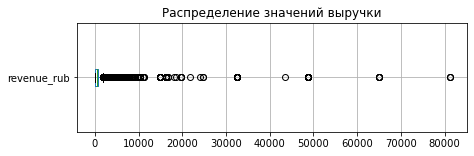

In [15]:
#Визуализируем 'revenue_rub' с помощью диаграммы размаха
plt.figure(figsize=(7, 2))

df.boxplot(column='revenue_rub', 
           vert=False)
plt.title('Распределение значений выручки')
plt.show()

In [16]:
#фильтруем значения столбца 'revenue_rub' по 99 перцентилю и убираем сначения менее 0
perc_99 = df['revenue_rub'].quantile(0.99)
df_wo_perc = df[(df['revenue_rub'] <= perc_99) & (df['revenue_rub'] >= 0)]
df_filtered = df_wo_perc.copy()

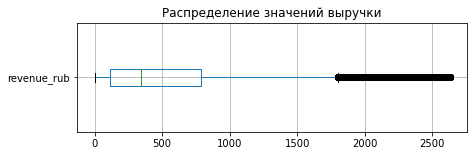

In [17]:
#Визуализируем 'revenue_rub' с помощью диаграммы размаха после удаления выбросов
plt.figure(figsize=(7, 2))

df_filtered.boxplot(column='revenue_rub', 
           vert=False)
plt.title('Распределение значений выручки')
plt.show()

In [18]:
print(f"Количество удаленных строк: {len(chk) - df_filtered.shape[0]}")
print(f"Доля удаленных строк от начального датафрейма: {((len(chk) - df_filtered.shape[0]) / len(chk)) * 100:.2f}%")

Количество удаленных строк: 3206
Доля удаленных строк от начального датафрейма: 1.10%


In [19]:
#Изучаем значения в основных столбцах. Изучаем 'tickets_count'
tickets_distribution = df['tickets_count'].value_counts()
tickets_distribution

3     92247
2     83807
4     54812
1     41798
5     13476
6      4283
7        62
9        38
8        21
10       19
11       13
13        7
17        6
19        5
14        4
12        4
15        2
27        2
30        2
47        1
57        1
37        1
Name: tickets_count, dtype: int64

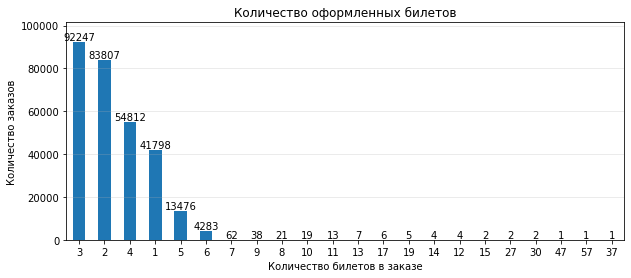

In [20]:
#Визуализируем 'tickets_count' с помощью гистограммы
plt.figure(figsize=(10, 4))
tickets_distribution.plot(
               kind='bar', 
               rot=0,
               legend=False,
               title=f'Количество оформленных билетов'
)

plt.xlabel('Количество билетов в заказе')
plt.ylabel('Количество заказов')
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, tickets_distribution.max() * 1.1)

for i, v in enumerate(tickets_distribution.values):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom')
    
plt.show()

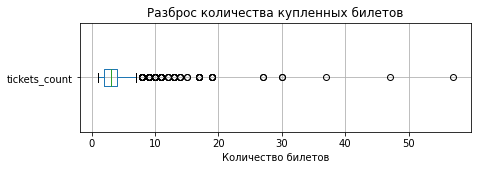

<Figure size 504x504 with 0 Axes>

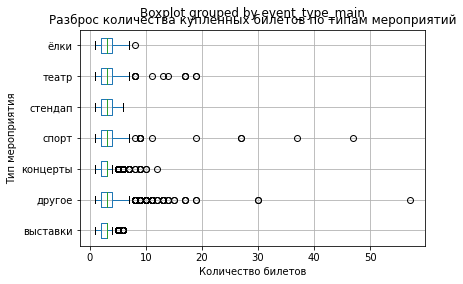

In [21]:
#Визуализируем 'tickets_count' с помощью диаграммы размаха
plt.figure(figsize=(7, 2))

df.boxplot(column='tickets_count', 
           vert=False)
plt.title('Разброс количества купленных билетов')
plt.xlabel('Количество билетов')
plt.show()

plt.figure(figsize=(7, 7))
df.boxplot(column='tickets_count', by='event_type_main', 
           vert=False)
plt.title('Разброс количества купленных билетов по типам мероприятий')
plt.xlabel('Количество билетов')
plt.ylabel('Тип мероприятия')
plt.show()

In [22]:
#Изучаем значения в основных столбцах. Изучаем 'device_type_canonical'
device_type_stats = pd.DataFrame({
    'count': df_filtered['device_type_canonical'].value_counts(),
    'share': (df_filtered['device_type_canonical'].value_counts(normalize=True).values * 100).round(1)
})
device_type_stats


,count,share
mobile,230102,80.1
desktop,57303,19.9


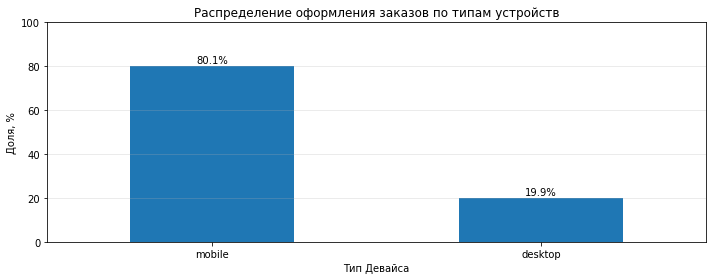

In [23]:
#Визуализируем 'device_type_stats' с помощью столбчатой диаграммы
plt.figure(figsize=(10, 4))

device_type_stats['share'].plot(
               kind='bar', 
               rot=0,
               legend=False,
               title=f'Распределение оформления заказов по типам устройств'
)

plt.xlabel('Тип Девайса')
plt.ylabel('Доля, %')
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 100)

for i, v in enumerate(device_type_stats['share']):
    plt.text(i, v + 0.5, str(v) + '%', ha='center', va='bottom')
    
plt.tight_layout()
plt.show()

In [24]:
#Изучаем значения в основных столбцах. Изучаем 'device_type_canonical'
orders_per_user = df_filtered['user_id'].value_counts()

user_freq_stats = pd.DataFrame({
    'orders_count': orders_per_user.value_counts().index,  # 1, 2, 3, 4... заказов
    'users_count': orders_per_user.value_counts().values,               # сколько пользователей
    'users_share': (orders_per_user.value_counts(normalize=True).values * 100).round(2)
}).sort_values('orders_count')
user_freq_stats

,orders_count,users_count,users_share
0,1,8363,38.30
1,2,3571,16.35
2,3,2171,9.94
3,4,1401,6.42
4,5,969,4.44
...,...,...,...
219,3710,1,0.00
220,3786,1,0.00
221,4014,1,0.00
281,4346,1,0.00


In [25]:
bins = [0, 1, 5, 15, 35, float('inf')]
labels = ['1 раз', '2-5 раза', '6-15 раз', '16-35 раз', '>35 раз']
user_freq_stats['category'] = pd.cut(user_freq_stats['orders_count'], bins=bins, labels=labels, right=True)
user_freq_bins = user_freq_stats.groupby('category')['users_count'].sum().reset_index()
user_freq_bins['users_share'] = (user_freq_bins['users_count'] / user_freq_bins['users_count'].sum() * 100).round(2)
user_freq_bins

,category,users_count,users_share
0,1 раз,8363,38.30
1,2-5 раза,8112,37.15
2,6-15 раз,3234,14.81
3,16-35 раз,1141,5.22
4,>35 раз,988,4.52


In [26]:
user_freq_stats['orders_count'].describe()

count      329.000000
mean       454.103343
std        876.049925
min          1.000000
25%         83.000000
50%        178.000000
75%        461.000000
max      10168.000000
Name: orders_count, dtype: float64

In [27]:
#Изучаем значения в основных столбцах. Изучаем 'order_dt'
min_date = df_filtered['order_dt'].min()
min_date

Timestamp('2024-06-01 00:00:00')

In [28]:
max_date = df_filtered['order_dt'].max()
max_date

Timestamp('2024-10-31 00:00:00')

In [29]:
revenue_month = df_filtered.groupby(df_filtered['order_dt'].dt.to_period('M'))['revenue_rub'].sum().reset_index()
revenue_month['month'] = revenue_month['order_dt'].dt.strftime('%B')
revenue_month['revenue_rub'] = revenue_month['revenue_rub'].astype(int)
revenue_month

,order_dt,revenue_rub,month
0,2024-06,19784568,June
1,2024-07,22571092,July
2,2024-08,24325136,August
3,2024-09,33403770,September
4,2024-10,48997940,October


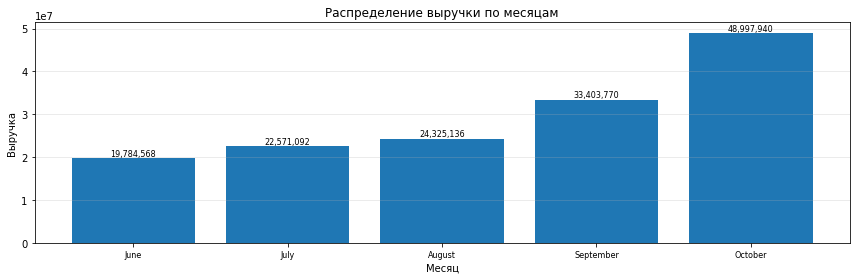

In [30]:
#Визуализируем 'revenue_month' с помощью столбчатой диаграммы
plt.figure(figsize=(12, 4))

plt.bar(range(len(revenue_month)), 
        revenue_month['revenue_rub'])

plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.title('Распределение выручки по месяцам')
plt.grid(axis='y', alpha=0.3)

plt.xticks(range(len(revenue_month)), revenue_month['month'], fontsize=8)

for i, v in enumerate(revenue_month['revenue_rub']):
    plt.text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=8)
    
plt.tight_layout()
plt.show()

In [31]:
#Изучаем значения в основных столбцах. Изучаем исменение стоимости билета в зависимости от 'event_type_main'
df_filtered.loc[:, 'revenue_per_ticket'] = df_filtered['revenue_rub'] / df_filtered['tickets_count']

cost_per_event = df_filtered.groupby('event_type_main')['revenue_per_ticket'].mean().reset_index()
cost_per_event = cost_per_event.sort_values('revenue_per_ticket', ascending=False)
cost_per_event

,event_type_main,revenue_per_ticket
2,концерты,284.036411
6,ёлки,236.015063
4,стендап,225.305909
5,театр,189.936834
0,выставки,89.307633
1,другое,77.148580
3,спорт,50.124758


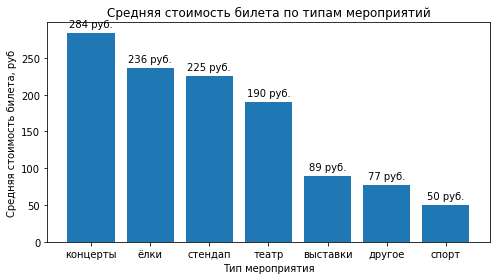

In [32]:
#Визуализируем 'revenue_per_ticket' в зависимости от типа мероприятия с помощью столбчатой диаграммы
plt.figure(figsize=(7, 4))
plt.bar(range(len(cost_per_event)), 
        cost_per_event['revenue_per_ticket'])

plt.xlabel('Тип мероприятия')
plt.ylabel('Средняя стоимость билета, руб')
plt.title('Средняя стоимость билета по типам мероприятий')

plt.xticks(range(len(cost_per_event)), 
           cost_per_event['event_type_main'], 
           ha='center')

for i, v in enumerate(cost_per_event['revenue_per_ticket']):
    plt.text(i, v + 5, f'{v:.0f} руб.', 
             ha='center', 
             va='bottom')
    
plt.tight_layout()
plt.show()

In [33]:
#Изучаем значения в основных столбцах. Изучаем исменение стоимости билета в зависимости от 'service_name'
df_filtered.loc[:, 'revenue_per_ticket'] = df_filtered['revenue_rub'] / df_filtered['tickets_count']

cost_per_service = df_filtered.groupby('service_name')['revenue_per_ticket'].mean().reset_index()
cost_per_service = cost_per_service.sort_values('revenue_per_ticket', ascending=False)
cost_per_service

,service_name,revenue_per_ticket
29,росбилет,570.410577
14,дырокол,470.430619
34,шоу начинается!,391.448215
19,край билетов,382.438372
8,весь в билетах,360.008330
7,быстрый кассир,354.849650
13,дом культуры,353.319806
23,мир касс,314.465469
33,цвет и билет,303.737439
6,быстробилет,303.619987


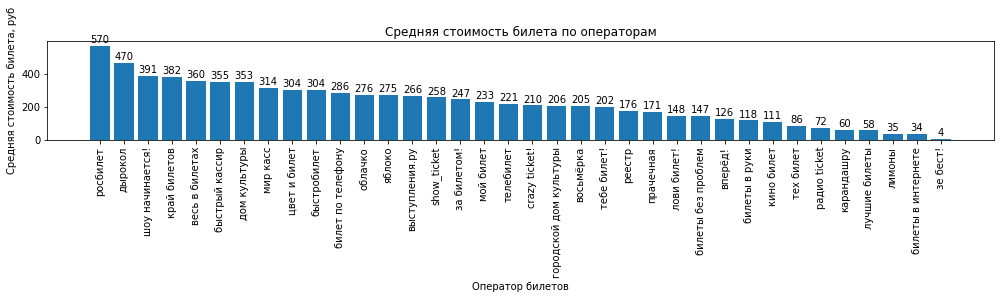

In [34]:
#Визуализируем 'revenue_per_ticket' в зависимости от оператора билетов с помощью столбчатой диаграммы
plt.figure(figsize=(14, 4))
plt.bar(range(len(cost_per_service)), 
        cost_per_service['revenue_per_ticket'])

plt.xlabel('Оператор билетов')
plt.ylabel('Средняя стоимость билета, руб')
plt.title('Средняя стоимость билета по операторам')

plt.xticks(range(len(cost_per_service)), 
           cost_per_service['service_name'], 
           rotation=90,
           ha='center')

for i, v in enumerate(cost_per_service['revenue_per_ticket']):
    plt.text(i, v + 5, f'{v:.0f}', 
             ha='center', 
             va='bottom')
    
plt.tight_layout()
plt.show()

In [35]:
#Изучаем значения в основных столбцах. Изучаем исменение стоимости билета в зависимости от 'region_name'
df_filtered.loc[:, 'revenue_per_ticket'] = df_filtered['revenue_rub'] / df_filtered['tickets_count']

cost_per_region = df_filtered.groupby('region_name')['revenue_per_ticket'].mean().reset_index()
cost_per_region = cost_per_region.sort_values('revenue_per_ticket', ascending=False)
cost_per_region

,region_name,revenue_per_ticket
68,теплоозёрский округ,440.447143
37,лесоярская область,398.566436
46,озернопольская область,379.879801
4,верховинская область,376.907470
7,ветренский регион,342.742464
...,...,...
35,лесополянская область,40.119638
29,кристаловская область,36.110293
25,каменноозёрный край,34.713016
58,североключевской округ,26.911443


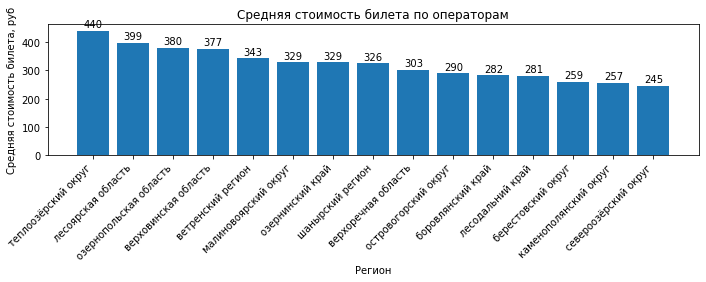

In [36]:
#Визуализируем 'revenue_per_ticket' в зависимости от региона с помощью столбчатой диаграммы
top15_regions = cost_per_region.sort_values('revenue_per_ticket', ascending=False).head(15)

plt.figure(figsize=(10, 4))
plt.bar(range(len(top15_regions)), 
        top15_regions['revenue_per_ticket'])

plt.xlabel('Регион')
plt.ylabel('Средняя стоимость билета, руб')
plt.title('Средняя стоимость билета по операторам')

plt.xticks(range(len(top15_regions)), 
           top15_regions['region_name'], 
           rotation=45,
           ha='right')

for i, v in enumerate(top15_regions['revenue_per_ticket']):
    plt.text(i, v + 5, f'{v:.0f}', 
             ha='center', 
             va='bottom')
    
plt.tight_layout()
plt.show()

**Задача 2:** Промежуточный вывод

- `revenue_rub`: статистические показатели по столбцу revenue_rub показали наличие выбросов (при среднем 454.1 стантартное отклонение равно 876 что говорит о большом размаше данных), а также отрицательные значения (минимальное значение составило -90.76 руб.). Была применена фильтрация по 99-му перцентилю, а также удалены все записи с отрицательной выручкой. В результате было удалено 3 206 строк, что составляет 1.1% от начального объёма данных. Такая доля исключений является незначительной.
- `tickets_count`: большинство заказов включают от 2 до 4 билетов. Наибольшее количество заказов приходится на 3 билета (92 247 заказов). Максимальное зафиксированное количество билетов в одном заказе — 57. Диаграмма размаха по типам мероприятий показывает, что распределение количества билетов существенно не меняется в зависимости от категории
- `device_type_canonical`: большинство заказов оформляется с мобильных устройств, 80.1% через mobile vs. 19.9% desktop.
- `user_id`: анализ количества заказов на одного пользователя показал наличие очень больших значений, что требует изучения. Есть очень активные пользователи. Максимальное количество заказов у одного пользователя за период 5 месяцев составило 10168, что не кажется реалистичным. 38.3% пользователей за 5 месяцев 1 раз купили билет, 37.15% от 2 до 5 раз, еще 14.81% от 6 до 15 раз, 5.22% от 16 до 35 раз и 4.52% более 35 раз.
- `order_dt`: в данных предоставлена информация за период июнь – октябрь 2024. Выручка имеет положительню динамику от месяца к месяцу и максимальное значение достигается в октябре 2024.
- `revenue_per_ticket` (выручка, делённая на количество билетов): был добавлен новый столбец для анализа стоимости одного билета в разных разрезах
- `revenue_per_ticket` vs `event_type_main`: cамые дорогие билеты в среднем продаются на кончерты (284 руб), самые бюджетные — спорт (50 руб).
    1. концерты 284 руб
    2. ёлки 236 руб 
    3. стендап 225 руб
    4. театр 189 руб
    5. выставки 89 руб
    6. другое 77 руб
    7. спорт 50 руб  
    
- `revenue_per_ticket` vs `service_name`: наблюдается сильный разброс в средней цене билета это может указывать на разный профиль мероприятий. Самыми дорогими операторами по средтей стоимости билетов являются
    1. росбилет 570 руб
    2. дырокол 470 руб
    3. шоу начинается! 391 руб
    
    а самыми бюджетными 
    1. лимоны 34 руб
    2. билеты в интернете 34 руб
    3. зе бест! 4 руб  

- `revenue_per_ticket` vs `region_name`: аналогичный разрос цен налюдается и по региотам. топ 3 региона по средней стоимости билетов являются 
    1. теплоозёрский округ 440 руб
    2. лесоярская область 398 руб
    3. озернопольская область 379 руб
    
    а самыми бюджетными 
    1. каменноозёрный край	34 руб
    2. североключевской округ	26 руб
    3. яснопольский округ	17 руб

Подготовленный датасет (`df_filtered`) готов к дальнейшему исследовательскому анализ.

###  3. Создание профиля пользователя

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавить два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортировать данные по времени совершения заказа.


In [37]:
#сортируем df_filtered по времени совершения заказа
df_filtered_ts_sort = df_filtered.sort_values(by='order_ts', ascending=True)

#uheggbhetv пользователей и проводим аггрегацию вычисляемых столбцов
users_df = df_filtered_ts_sort.groupby('user_id').agg(
    first_order=('order_ts', 'min'),
    last_order=('order_ts', 'max'),
    orders_count=('order_id', 'nunique'),
    avg_order_revenue=('revenue_rub', 'mean'),
    avg_tickets_count=('tickets_count', 'mean'),
    avg_days_since_prev=('days_since_prev', 'mean'),
    avg_ticket_revenue=('revenue_per_ticket', 'mean')
).reset_index()

users_df

,user_id,first_order,last_order,orders_count,avg_order_revenue,avg_tickets_count,avg_days_since_prev,avg_ticket_revenue
0,0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03,1,1521.940000,4.000000,NaN,380.485000
1,0005ca5e93f2cf4,2024-07-23 18:36:24,2024-10-06 13:56:02,2,774.010000,3.000000,75.000,229.683750
2,000898990054619,2024-07-13 19:40:48,2024-10-23 15:12:00,3,767.213333,2.666667,51.000,256.209444
3,00096d1f542ab2b,2024-08-15 16:48:48,2024-08-15 16:48:48,1,917.830000,4.000000,NaN,229.457500
4,000a55a418c128c,2024-09-29 19:39:12,2024-10-15 10:29:04,2,61.310000,1.500000,16.000,42.600000
...,...,...,...,...,...,...,...,...
21833,fff13b79bd47d7c,2024-07-16 22:17:10,2024-10-31 18:31:52,9,688.043333,2.555556,13.375,302.947093
21834,fff32fc9ad0f9f6,2024-08-15 14:36:28,2024-10-28 23:40:38,2,850.995000,2.500000,74.000,360.498333
21835,fffcd3dde79eb2c,2024-06-20 19:57:25,2024-10-30 13:37:43,33,557.908485,2.787879,4.125,208.751061
21836,fffeeb3c120cf0b,2024-09-24 10:07:42,2024-09-24 10:07:42,1,661.530000,2.000000,NaN,330.765000


In [38]:
#обогащаем полученные данные категориальными данными по пользователях из основного датасета
users_df = users_df.merge(
    df_filtered_ts_sort[['user_id', 'order_ts', 'device_type_canonical', 'region_name', 'service_name', 'event_type_main']], 
    left_on=['user_id', 'first_order'], 
    right_on=['user_id', 'order_ts']
)
users_df

,user_id,first_order,last_order,orders_count,avg_order_revenue,avg_tickets_count,avg_days_since_prev,avg_ticket_revenue,order_ts,device_type_canonical,region_name,service_name,event_type_main
0,0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03,1,1521.940000,4.000000,NaN,380.485000,2024-08-20 16:08:03,mobile,каменевский регион,край билетов,театр
1,0005ca5e93f2cf4,2024-07-23 18:36:24,2024-10-06 13:56:02,2,774.010000,3.000000,75.000,229.683750,2024-07-23 18:36:24,mobile,каменевский регион,мой билет,выставки
2,000898990054619,2024-07-13 19:40:48,2024-10-23 15:12:00,3,767.213333,2.666667,51.000,256.209444,2024-07-13 19:40:48,mobile,североярская область,лови билет!,другое
3,00096d1f542ab2b,2024-08-15 16:48:48,2024-08-15 16:48:48,1,917.830000,4.000000,NaN,229.457500,2024-08-15 16:48:48,desktop,каменевский регион,край билетов,театр
4,000a55a418c128c,2024-09-29 19:39:12,2024-10-15 10:29:04,2,61.310000,1.500000,16.000,42.600000,2024-09-29 19:39:12,mobile,поленовский край,лучшие билеты,театр
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21833,fff13b79bd47d7c,2024-07-16 22:17:10,2024-10-31 18:31:52,9,688.043333,2.555556,13.375,302.947093,2024-07-16 22:17:10,mobile,каменевский регион,мой билет,другое
21834,fff32fc9ad0f9f6,2024-08-15 14:36:28,2024-10-28 23:40:38,2,850.995000,2.500000,74.000,360.498333,2024-08-15 14:36:28,desktop,каменевский регион,билеты без проблем,стендап
21835,fffcd3dde79eb2c,2024-06-20 19:57:25,2024-10-30 13:37:43,33,557.908485,2.787879,4.125,208.751061,2024-06-20 19:57:25,desktop,каменевский регион,билеты без проблем,концерты
21836,fffeeb3c120cf0b,2024-09-24 10:07:42,2024-09-24 10:07:42,1,661.530000,2.000000,NaN,330.765000,2024-09-24 10:07:42,desktop,широковская область,билеты без проблем,стендап


In [39]:
#добавляем бинарные признаки
users_df['is_five'] = (users_df['orders_count'] >= 5).astype(int)
users_df['is_two'] = (users_df['orders_count'] >= 2).astype(int)

users_df['is_five'] = pd.to_numeric(users_df['is_five'], downcast='integer')
users_df['is_two'] = pd.to_numeric(users_df['is_two'], downcast='integer')

users_df.head()

,user_id,first_order,last_order,orders_count,avg_order_revenue,avg_tickets_count,avg_days_since_prev,avg_ticket_revenue,order_ts,device_type_canonical,region_name,service_name,event_type_main,is_five,is_two
0,0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03,1,1521.940000,4.000000,NaN,380.485000,2024-08-20 16:08:03,mobile,каменевский регион,край билетов,театр,0,0
1,0005ca5e93f2cf4,2024-07-23 18:36:24,2024-10-06 13:56:02,2,774.010000,3.000000,75.0,229.683750,2024-07-23 18:36:24,mobile,каменевский регион,мой билет,выставки,0,1
2,000898990054619,2024-07-13 19:40:48,2024-10-23 15:12:00,3,767.213333,2.666667,51.0,256.209444,2024-07-13 19:40:48,mobile,североярская область,лови билет!,другое,0,1
3,00096d1f542ab2b,2024-08-15 16:48:48,2024-08-15 16:48:48,1,917.830000,4.000000,NaN,229.457500,2024-08-15 16:48:48,desktop,каменевский регион,край билетов,театр,0,0
4,000a55a418c128c,2024-09-29 19:39:12,2024-10-15 10:29:04,2,61.310000,1.500000,16.0,42.600000,2024-09-29 19:39:12,mobile,поленовский край,лучшие билеты,театр,0,1


**Задача 3.1:** Промежуточный вывод

Профиль пользователя построен.  
Бинарные признаки добавлены.  

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке
- среднюю выручку с одного заказа
- долю пользователей, совершивших 2 и более заказа
- долю пользователей, совершивших 5 и более заказов

Также изучите статистические показатели:

- по общему числу заказов
- по среднему числу билетов в заказе
- по среднему количеству дней между покупками

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [40]:
users_chk = users_df.copy() 
len(users_chk)

21838

In [41]:
#Статистические данные о пользователях и заказах
print("Статистические данные о пользователях")
print(f"общее число пользователей в выборке: {users_df.shape[0]} (пользователи)")
print(f"средняя выручка с одного заказа: {users_df['avg_order_revenue'].mean():.2f} (руб)")
print(f"доля пользователей, совершивших 2+ заказа: {users_df['is_two'].sum()/users_df.shape[0]*100:.2f} (%)")
print(f"доля пользователей, совершивших 5+ заказов: {users_df['is_five'].sum()/users_df.shape[0]*100:.2f} (%)")
print()
print("Статистические данные о заказах")
print(f"общее число заказов: {users_df['orders_count'].sum()} (заказы)")
print(f"среднее число билетов в заказе: {users_df['avg_tickets_count'].mean():.0f} (билеты)")
print(f"среднее количество дней между покупками: {users_df['avg_days_since_prev'].mean():.0f} (дни)")

Статистические данные о пользователях
общее число пользователей в выборке: 21838 (пользователи)
средняя выручка с одного заказа: 545.03 (руб)
доля пользователей, совершивших 2+ заказа: 61.70 (%)
доля пользователей, совершивших 5+ заказов: 29.00 (%)

Статистические данные о заказах
общее число заказов: 287405 (заказы)
среднее число билетов в заказе: 3 (билеты)
среднее количество дней между покупками: 16 (дни)


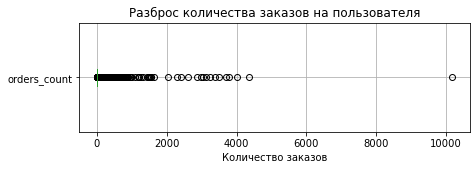

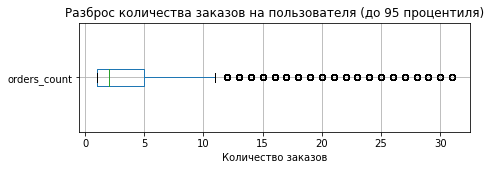

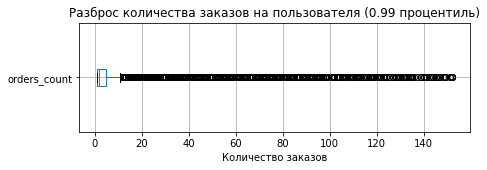

In [42]:
#Строим диаграмму размаха значений по столбцу orders_count
plt.figure(figsize=(7, 2))
users_df.boxplot(column='orders_count', 
           vert=False)

plt.title('Разброс количества заказов на пользователя')
plt.xlabel('Количество заказов')
plt.show()

#Строим диаграмму размаха значений в столбце orders_count отчекая значения после 95 процентиля
plt.figure(figsize=(7, 2))
uperc_95 = users_df['orders_count'].quantile(0.95)
uperc_95_df = users_df[users_df['orders_count'] <= uperc_95]
uperc_95_df.boxplot(column='orders_count', vert=False)
plt.title('Разброс количества заказов на пользователя (до 95 процентиля)')
plt.xlabel('Количество заказов')
plt.show()

#Строим диаграмму размаха значений в столбце orders_count отчекая значения после 99 процентиля
plt.figure(figsize=(7, 2))
uperc_99 = users_df['orders_count'].quantile(0.99)
uperc_99_df = users_df[users_df['orders_count'] <= uperc_99]
uperc_99_df.boxplot(column='orders_count', vert=False)
plt.title('Разброс количества заказов на пользователя (0.99 процентиль)')
plt.xlabel('Количество заказов')
plt.show()

In [43]:
#принимаю решение использовать 95 процентиль как граница для отсекания выбросов по количеству заказов
users_df = users_df[users_df['orders_count'] <= uperc_95]

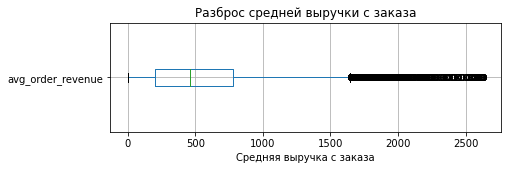

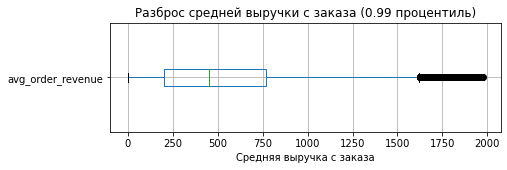

In [44]:
#Строим диаграмму размаха значений по столбцу avg_order_revenue
plt.figure(figsize=(7, 2))
users_df.boxplot(column='avg_order_revenue', 
           vert=False)

plt.title('Разброс средней выручки с заказа')
plt.xlabel('Средняя выручка с заказа')
plt.show()

#Строим диаграмму размаха значений по столбцу avg_order_revenue отcекая значения после 99 процентиля
plt.figure(figsize=(7, 2))
operc_99 = users_df['avg_order_revenue'].quantile(0.99)
operc_99_df = users_df[users_df['avg_order_revenue'] <= operc_99]
operc_99_df.boxplot(column='avg_order_revenue', 
           vert=False)

plt.title('Разброс средней выручки с заказа (0.99 процентиль)')
plt.xlabel('Средняя выручка с заказа')
plt.show()

In [45]:
#принимаю решение использовать 99 процентиль как граница для отсекания выбросов по выручке с заказа
users_df = users_df[users_df['avg_order_revenue'] <= operc_99]

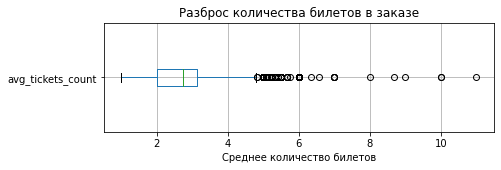

In [46]:
#Строим диаграмму размаха значений по столбцу avg_tickets_count
plt.figure(figsize=(7, 2))
users_df.boxplot(column='avg_tickets_count', 
           vert=False)

plt.title('Разброс количества билетов в заказе')
plt.xlabel('Среднее количество билетов')
plt.show()

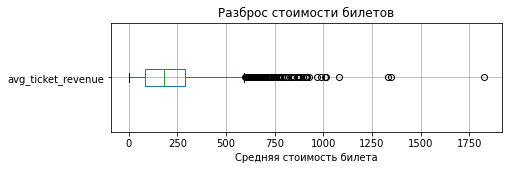

In [47]:
#Строим диаграмму размаха значений по столбцу avg_ticket_revenue
plt.figure(figsize=(7, 2))
users_df.boxplot(column='avg_ticket_revenue', 
           vert=False)

plt.title('Разброс стоимости билетов')
plt.xlabel('Средняя стоимость билета')
plt.show()

In [48]:
#Статистические данные о пользователях и заказах
print("Статистические данные о пользователях")
print(f"общее число пользователей в выборке: {users_df.shape[0]} (пользователи)")
print(f"средняя выручка с одного заказа: {users_df['avg_order_revenue'].mean():.2f} (руб)")
print(f"доля пользователей, совершивших 2+ заказа: {users_df['is_two'].sum()/users_df.shape[0]*100:.2f} (%)")
print(f"доля пользователей, совершивших 5+ заказов: {users_df['is_five'].sum()/users_df.shape[0]*100:.2f} (%)")
print()
print("Статистические данные о заказах")
print(f"общее число заказов: {users_df['orders_count'].sum()} (заказы)")
print(f"среднее число билетов в заказе: {users_df['avg_tickets_count'].mean():.0f} (билеты)")
print(f"среднее количество дней между покупками: {users_df['avg_days_since_prev'].mean():.0f} (дни)")

Статистические данные о пользователях
общее число пользователей в выборке: 20539 (пользователи)
средняя выручка с одного заказа: 530.04 (руб)
доля пользователей, совершивших 2+ заказа: 60.05 (%)
доля пользователей, совершивших 5+ заказов: 25.49 (%)

Статистические данные о заказах
общее число заказов: 83699 (заказы)
среднее число билетов в заказе: 3 (билеты)
среднее количество дней между покупками: 17 (дни)


In [49]:
print(f"Oбъём первоначальных данных по пользователям: {len(users_chk)}")
print(f"Oбъём отфильтрованных данных: {len(chk) - users_df.shape[0]}")
print(f"Доля отфильтрованных данных от начального датафрейма users_df: {((len(users_chk) - users_df.shape[0]) / len(users_chk)) * 100:.2f}%")

Oбъём первоначальных данных по пользователям: 21838
Oбъём отфильтрованных данных: 270072
Доля отфильтрованных данных от начального датафрейма users_df: 5.95%


In [50]:
users_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 20539 entries, 0 to 21837
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                20539 non-null  object        
 1   first_order            20539 non-null  datetime64[ns]
 2   last_order             20539 non-null  datetime64[ns]
 3   orders_count           20539 non-null  int64         
 4   avg_order_revenue      20539 non-null  float64       
 5   avg_tickets_count      20539 non-null  float64       
 6   avg_days_since_prev    12362 non-null  float64       
 7   avg_ticket_revenue     20539 non-null  float64       
 8   order_ts               20539 non-null  datetime64[ns]
 9   device_type_canonical  20539 non-null  object        
 10  region_name            20539 non-null  object        
 11  service_name           20539 non-null  object        
 12  event_type_main        20539 non-null  object        
 13  i

**Задача 3.2:** Промежуточный вывод

Была проведена оценка выборки пользователей и выявление аномалий.
Входные статистические данные о пользователях
- общее число пользователей в выборке: 21838 (пользователи)
- средняя выручка с одного заказа: 545.03 (руб)
- доля пользователей, совершивших 2+ заказа: 61.70 (%)
- доля пользователей, совершивших 5+ заказов: 29.00 (%)
- общее число заказов: 287405 (заказы)
- среднее число билетов в заказе: 3 (билеты)
- среднее количество дней между покупками: 16 (дни)

Аномалии в данных:
- orders_count: диаграмма размаха показала экстремальные выбросы. их же видели на этапе изучения данных. Принято решение отфильтровать данные по 95 перцентилю.
- avg_order_revenue: также обнаружены выбросы. Принято решение: отфильтровать данные по 99 перцентилю.

Выходные статистические данные о пользователях:
- общее число пользователей в выборке: 20539 (пользователи) - сокращение на 5.95%
- средняя выручка с одного заказа: 530.04 (руб) - сокращение на 2.8%
- доля пользователей, совершивших 2+ заказа: 60.05 (%) - сокращение на 1.65пп
- доля пользователей, совершивших 5+ заказов: 25.49 (%) - сокращение на 3.51пп
- общее число заказов: 83699 (заказы) - сокращение на 70.9%
- среднее число билетов в заказе: 3 (билеты) - без динамики
- среднее количество дней между покупками: 17 (дни) - увеличение на 1 день

**Итого:** при удалении всего 5.95% пользователей количество заказов сократилось на 70.9%. Это подтверждает, что небольшая группа очень активных пользователей (с количеством заказов выше 95 перцентиля) генерировала основную массу заказов. Полученные показатели с высокой вероятностью отражают поведение типичного пользователя и могут использоваться для для дальнейшего анализа для принятия бизнес-решений.

### 4. Исследовательский анализ данных

Исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.

#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу
Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

Сгруппируйте пользователей:
- по типу их первого мероприятия;
- по типу устройства, с которого совершена первая покупка;
- по региону проведения мероприятия из первого заказа;
- по билетному оператору, продавшему билеты на первый заказ.

Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.

**Ответьте на вопрос:** равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

In [51]:
#Добавляем признак толго вернулся пользователь или нет
users_df['is_return'] = (users_df['orders_count'] > 1).astype(int)
users_df.head()

,user_id,first_order,last_order,orders_count,avg_order_revenue,avg_tickets_count,avg_days_since_prev,avg_ticket_revenue,order_ts,device_type_canonical,region_name,service_name,event_type_main,is_five,is_two,is_return
0,0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03,1,1521.940000,4.000000,NaN,380.485000,2024-08-20 16:08:03,mobile,каменевский регион,край билетов,театр,0,0,0
1,0005ca5e93f2cf4,2024-07-23 18:36:24,2024-10-06 13:56:02,2,774.010000,3.000000,75.0,229.683750,2024-07-23 18:36:24,mobile,каменевский регион,мой билет,выставки,0,1,1
2,000898990054619,2024-07-13 19:40:48,2024-10-23 15:12:00,3,767.213333,2.666667,51.0,256.209444,2024-07-13 19:40:48,mobile,североярская область,лови билет!,другое,0,1,1
3,00096d1f542ab2b,2024-08-15 16:48:48,2024-08-15 16:48:48,1,917.830000,4.000000,NaN,229.457500,2024-08-15 16:48:48,desktop,каменевский регион,край билетов,театр,0,0,0
4,000a55a418c128c,2024-09-29 19:39:12,2024-10-15 10:29:04,2,61.310000,1.500000,16.0,42.600000,2024-09-29 19:39:12,mobile,поленовский край,лучшие билеты,театр,0,1,1


In [52]:
#Группируем пользователей по типу их первого мероприятия
by_event = users_df.groupby(['is_return', 'event_type_main']).size().reset_index(name='users_count')
pivot_by_event = by_event.pivot(index='event_type_main', columns='is_return', values='users_count').fillna(0)
pivot_by_event.columns = ['not_returned_abs', 'returned_abs']
pivot_by_event['total_users'] = pivot_by_event['not_returned_abs'] + pivot_by_event['returned_abs']
pivot_by_event['share'] = (pivot_by_event['total_users']/pivot_by_event['total_users'].sum() * 100).round(2)

# Считаем доли внутри каждой категории
pivot_by_event['not_returned_share'] = (pivot_by_event['not_returned_abs'] / pivot_by_event['total_users'] * 100).round(0)
pivot_by_event['returned_share'] = (pivot_by_event['returned_abs'] / pivot_by_event['total_users'] * 100).round(0)
pivot_by_event_sorted = pivot_by_event.sort_values('total_users', ascending=False)
pivot_by_event_sorted

,not_returned_abs,returned_abs,total_users,share,not_returned_share,returned_share
event_type_main,,,,,,
концерты,3540,5500,9040,44.01,39.0,61.0
другое,2174,2972,5146,25.05,42.0,58.0
театр,1522,2509,4031,19.63,38.0,62.0
стендап,430,634,1064,5.18,40.0,60.0
спорт,351,414,765,3.72,46.0,54.0
выставки,148,253,401,1.95,37.0,63.0
ёлки,40,52,92,0.45,43.0,57.0


<Figure size 504x288 with 0 Axes>

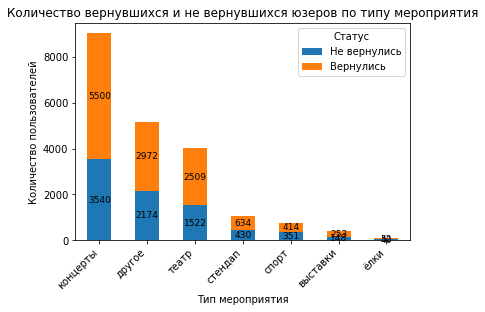

In [53]:
#Визуализируем вернувшихся и невернувшихся пользователей по типу их первого мероприятия
plt.figure(figsize=(7, 4))
pivot_by_event_sorted[['not_returned_abs', 'returned_abs']].plot(kind='bar', stacked=True)

plt.xlabel('Тип мероприятия')
plt.ylabel('Количество пользователей')
plt.title('Количество вернувшихся и не вернувшихся юзеров по типу мероприятия')
plt.legend(['Не вернулись', 'Вернулись'], title='Статус')
plt.xticks(rotation=45, ha='right')

for container in plt.gca().containers:
    plt.gca().bar_label(container, label_type='center', fontsize=9)

plt.show()

In [54]:
#Группируем пользователей по типу устройства, с которого совершена первая покупка
by_device = users_df.groupby(['is_return', 'device_type_canonical']).size().reset_index(name='users_count')
pivot_by_device = by_device.pivot(index='device_type_canonical', columns='is_return', values='users_count').fillna(0)
pivot_by_device.columns = ['not_returned_abs', 'returned_abs']
pivot_by_device['total_users'] = pivot_by_device['not_returned_abs'] + pivot_by_device['returned_abs']
pivot_by_device['share'] = (pivot_by_device['total_users']/pivot_by_device['total_users'].sum() * 100).round(2)

# Считаем доли внутри каждой категории
pivot_by_device['not_returned_share'] = (pivot_by_device['not_returned_abs'] / pivot_by_device['total_users'] * 100).round(0)
pivot_by_device['returned_share'] = (pivot_by_device['returned_abs'] / pivot_by_device['total_users'] * 100).round(0)
pivot_by_device

,not_returned_abs,returned_abs,total_users,share,not_returned_share,returned_share
device_type_canonical,,,,,,
desktop,1309,2184,3493,17.01,37.0,63.0
mobile,6896,10150,17046,82.99,40.0,60.0


<Figure size 504x288 with 0 Axes>

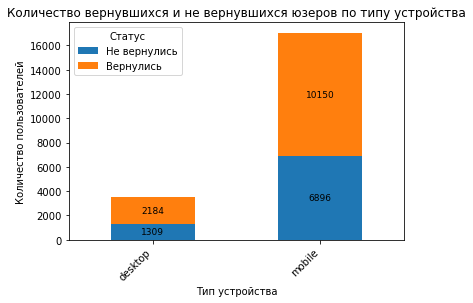

In [55]:
#Визуализируем вернувшихся и невернувшихся пользователей по типу устройства, с которого совершена первая покупка
plt.figure(figsize=(7, 4))
pivot_by_device[['not_returned_abs', 'returned_abs']].plot(kind='bar', stacked=True)

plt.xlabel('Тип устройства')
plt.ylabel('Количество пользователей')
plt.title('Количество вернувшихся и не вернувшихся юзеров по типу устройства')
plt.legend(['Не вернулись', 'Вернулись'], title='Статус')
plt.xticks(rotation=45, ha='right')

for container in plt.gca().containers:
    plt.gca().bar_label(container, label_type='center', fontsize=9)

plt.show()

In [56]:
#Группируем пользователей пo билетному оператору, продавшему билеты на первый заказ
by_service = users_df.groupby(['is_return', 'service_name']).size().reset_index(name='users_count')
pivot_by_service = by_service.pivot(index='service_name', columns='is_return', values='users_count').fillna(0)
pivot_by_service.columns = ['not_returned_abs', 'returned_abs']
pivot_by_service['total_users'] = pivot_by_service['not_returned_abs'] + pivot_by_service['returned_abs']
pivot_by_service['share'] = (pivot_by_service['total_users']/pivot_by_service['total_users'].sum() * 100).round(2)

# Считаем доли внутри каждой категории
pivot_by_service['not_returned_share'] = (pivot_by_service['not_returned_abs'] / pivot_by_service['total_users'] * 100).round(0)
pivot_by_service['returned_share'] = (pivot_by_service['returned_abs'] / pivot_by_service['total_users'] * 100).round(0)
pivot_by_service_sorted = pivot_by_service.sort_values('total_users', ascending=False)
pivot_by_service_sorted

,not_returned_abs,returned_abs,total_users,share,not_returned_share,returned_share
service_name,,,,,,
билеты без проблем,2023.0,2900.0,4923.0,23.97,41.0,59.0
мой билет,1139.0,1676.0,2815.0,13.71,40.0,60.0
лови билет!,1084.0,1606.0,2690.0,13.10,40.0,60.0
билеты в руки,943.0,1469.0,2412.0,11.74,39.0,61.0
облачко,826.0,1261.0,2087.0,10.16,40.0,60.0
весь в билетах,458.0,749.0,1207.0,5.88,38.0,62.0
лучшие билеты,456.0,673.0,1129.0,5.50,40.0,60.0
прачечная,214.0,332.0,546.0,2.66,39.0,61.0
край билетов,153.0,278.0,431.0,2.10,35.0,65.0


In [57]:
mean_returned_share_service = round(pivot_by_service_sorted['returned_share'].mean())
print(f"Средняя доля вернувшихся по операторам: {mean_returned_share_service}%")

Средняя доля вернувшихся по операторам: 60%


<Figure size 1440x144 with 0 Axes>

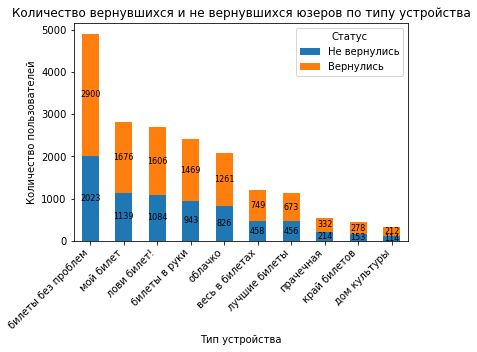

In [58]:
#Визуализируем вернувшихся и невернувшихся пользователей пo билетному оператору, продавшему билеты на первый заказ
plt_by_service_sorted = pivot_by_service_sorted.head(10)

plt.figure(figsize=(20, 2))
plt_by_service_sorted[['not_returned_abs', 'returned_abs']].plot(kind='bar', stacked=True)

plt.xlabel('Тип устройства')
plt.ylabel('Количество пользователей')
plt.title('Количество вернувшихся и не вернувшихся юзеров по типу устройства')
plt.legend(['Не вернулись', 'Вернулись'], title='Статус')
plt.xticks(rotation=45, ha='right')

for container in plt.gca().containers:
    plt.gca().bar_label(container, label_type='center', fontsize=8)

plt.show()

In [59]:
#Группируем пользователей по региону первого заказа
by_region = users_df.groupby(['is_return', 'region_name']).size().reset_index(name='users_count')
pivot_by_region = by_region.pivot(index='region_name', columns='is_return', values='users_count').fillna(0)
pivot_by_region.columns = ['not_returned_abs', 'returned_abs']
pivot_by_region['total_users'] = pivot_by_region['not_returned_abs'] + pivot_by_region['returned_abs']
pivot_by_region['share'] = (pivot_by_region['total_users']/pivot_by_region['total_users'].sum() * 100).round(2)

# Считаем доли внутри каждой категории
pivot_by_region['not_returned_share'] = (pivot_by_region['not_returned_abs'] / pivot_by_region['total_users'] * 100).round(0)
pivot_by_region['returned_share'] = (pivot_by_region['returned_abs'] / pivot_by_region['total_users'] * 100).round(0)
pivot_by_region_sorted = pivot_by_region.sort_values('total_users', ascending=False)
pivot_by_region_sorted

,not_returned_abs,returned_abs,total_users,share,not_returned_share,returned_share
region_name,,,,,,
каменевский регион,2594.0,4101.0,6695.0,32.60,39.0,61.0
североярская область,1347.0,2235.0,3582.0,17.44,38.0,62.0
широковская область,424.0,743.0,1167.0,5.68,36.0,64.0
озернинский край,295.0,355.0,650.0,3.16,45.0,55.0
малиновоярский округ,217.0,282.0,499.0,2.43,43.0,57.0
...,...,...,...,...,...,...
залесский край,1.0,1.0,2.0,0.01,50.0,50.0
верхозёрский край,0.0,1.0,1.0,0.00,0.0,100.0
светолесский край,1.0,0.0,1.0,0.00,100.0,0.0


In [60]:
mean_returned_share_region = round(pivot_by_region_sorted['returned_share'].mean())
print(f"Средняя доля вернувшихся по регионам: {mean_returned_share_region}%")

Средняя доля вернувшихся по регионам: 53%


<Figure size 2160x720 with 0 Axes>

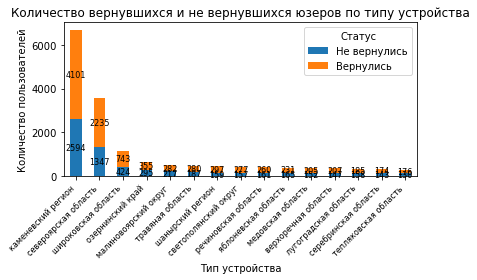

In [61]:
#Визуализируем вернувшихся и невернувшихся пользователей по региону первого заказа
plt_by_region_sorted = pivot_by_region_sorted.head(15)

plt.figure(figsize=(30, 10))
plt_by_region_sorted[['not_returned_abs', 'returned_abs']].plot(kind='bar', stacked=True)

plt.xlabel('Тип устройства')
plt.ylabel('Количество пользователей')
plt.title('Количество вернувшихся и не вернувшихся юзеров по типу устройства')
plt.legend(['Не вернулись', 'Вернулись'], title='Статус')
plt.xticks(rotation=45, ha='right', fontsize=8)

for container in plt.gca().containers:
    plt.gca().bar_label(container, label_type='center', fontsize=8)
plt.tight_layout()
plt.show()

**Задача 4.1.1.** Промежуточный вывод

Распределение данных неравномерное. Есть ярко выраженные точки-входа:

- `event_type_main`: почти половина всех пользователей (44%) начинают с концертов. Tоп-3 категории (концерты, другое, театр) покрывают 88.7% всех пользователей. Остальные 4 категории — занимают 11.3%. При этом доля вернушихся в каждом тибе мероприятия близка, и имеет несильный размах от 54% до 63%;
- `device_type_canonical`: более 80% пользователей приходят с mobile. При этом доля вернушихся 63% vs 60% на desktop, разница незначительна;
- `service_name`: данные также распределены неравномерно, но тут это более ожидаемо т.к. операторы могут быть локальными или федеральными, в больших и маленьких городах. 'билеты без проблем' — на первом месте - 24% пользователей приходит через этого оператора. Топ-5 операторов: покрывают 72.7% всех пользователей. Топ-7 операторов: 84.1% всех пользователей. Остальные 26 операторов делят между собой 15.9% пользователей. Доля вернувшихся у основных операторов в диапазоне 59-62%. Операторы с малой базой показывают больший разброс, что нормально т.к. по маленькой базе статистически богут быть ошибки.
- `region_name`: данные также неравномерные. Первые 2 региона покрывают 50% пользователей: каменевский регион 32.6% и североярская область 17.4%. остальные регионы уже с третьего места имеют небольшие веса, менее 6%.

**Задача 4.1.2.** Проанализируйте возвраты пользователей:  

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.

**Ответьте на вопросы:**
- Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
- Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?
- При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

In [62]:
#Рассчитаем среднюю долю пользователей совершивших два и более заказов
overall_return_rate = (users_df['is_two'].sum() / len(users_df) * 100).round(1)
print(f"Средняя доля пользователей совершивших два и более заказов: {overall_return_rate}%")

Средняя доля пользователей совершивших два и более заказов: 60.1%


In [63]:
#Группируем пользователей совершивших два и более заказов в зависимости от девайса
pivot_by_device_is_two = pd.crosstab(users_df['device_type_canonical'], users_df['is_two'], values=None, normalize='index')*100
pivot_by_device_is_two

is_two,0,1
device_type_canonical,,
desktop,37.474950,62.525050
mobile,40.455239,59.544761


<Figure size 504x288 with 0 Axes>

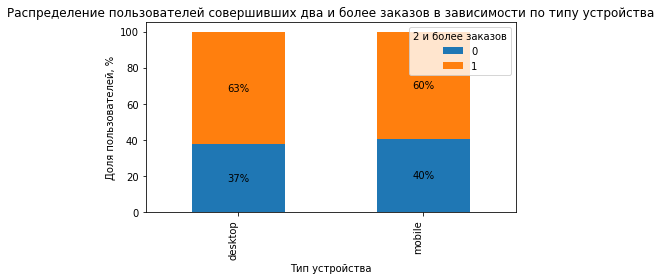

In [64]:
#Визуализируем распределение пользователей совершивших два и более заказов в зависимости от девайса
plt.figure(figsize=(7, 4))
pivot_by_device_is_two.plot(kind='bar', stacked=True)

plt.title('Распределение пользователей совершивших два и более заказов в зависимости по типу устройства')
plt.xlabel('Тип устройства')
plt.ylabel('Доля пользователей, %')
plt.legend(['0', '1'], title='2 и более заказов')
plt.xticks(ha='right')

for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.0f%%', label_type='center', fontsize=10)

plt.tight_layout()
plt.show()

In [65]:
#Группируем пользователей совершивших два и более заказов в зависимости от типа мероприятия
pivot_by_event_is_two = pd.crosstab(users_df['event_type_main'], users_df['is_two'], values=None, normalize='index')*100
pivot_by_event_is_two

is_two,0,1
event_type_main,,
выставки,36.907731,63.092269
другое,42.246405,57.753595
концерты,39.159292,60.840708
спорт,45.882353,54.117647
стендап,40.413534,59.586466
театр,37.757380,62.242620
ёлки,43.478261,56.521739


<Figure size 504x288 with 0 Axes>

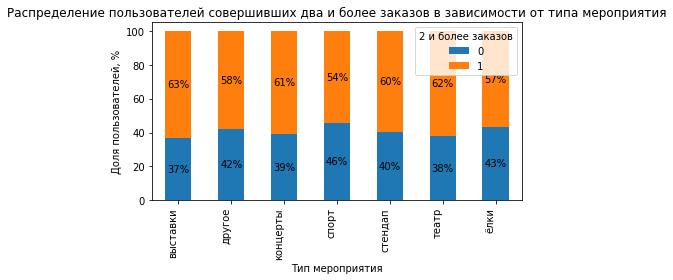

In [66]:
#Визуализируем распределение пользователей совершивших два и более заказов в зависимости от типа мероприятия
plt.figure(figsize=(7, 4))
pivot_by_event_is_two.plot(kind='bar', stacked=True)

plt.title('Распределение пользователей совершивших два и более заказов в зависимости от типа мероприятия')
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля пользователей, %')
plt.legend(['0', '1'], title='2 и более заказов')
plt.xticks(ha='right')

for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.0f%%', label_type='center', fontsize=10)

plt.tight_layout()
plt.show()

In [67]:
#Группируем пользователей овершивших два и более заказов в зависимости от билетного оператора
total_users_by_service = users_df.groupby('service_name').size()

pivot_by_service_is_two = pd.crosstab(users_df['service_name'], users_df['is_two'], values=None, normalize='index')*100
pivot_by_service_is_two['total_users'] = total_users_by_service
pivot_by_service_is_two_sorted = pivot_by_service_is_two.sort_values('total_users', ascending=False)
pivot_by_service_is_two_sorted

is_two,0,1,total_users
service_name,,,
билеты без проблем,41.092830,58.907170,4923
мой билет,40.461812,59.538188,2815
лови билет!,40.297398,59.702602,2690
билеты в руки,39.096186,60.903814,2412
облачко,39.578342,60.421658,2087
весь в билетах,37.945319,62.054681,1207
лучшие билеты,40.389725,59.610275,1129
прачечная,39.194139,60.805861,546
край билетов,35.498840,64.501160,431


<Figure size 504x288 with 0 Axes>

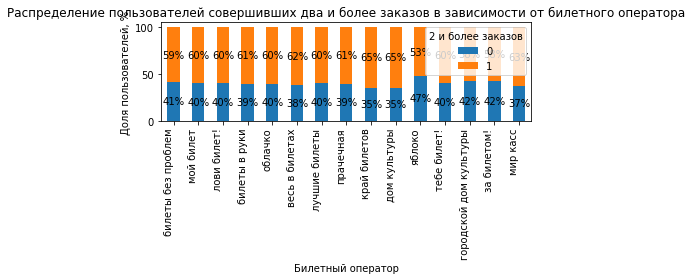

In [68]:
#Визуализируем распределение пользователей совершивших два и более заказов в зависимости от билетного оператора
plt_by_service_is_two_sorted = pivot_by_service_is_two_sorted.head(15)

plt.figure(figsize=(7, 4))
plt_by_service_is_two_sorted[[0, 1]].plot(kind='bar', stacked=True)

plt.title('Распределение пользователей совершивших два и более заказов в зависимости от билетного оператора')
plt.xlabel('Билетный оператор')
plt.ylabel('Доля пользователей, %')
plt.legend(['0', '1'], title='2 и более заказов')
plt.xticks(ha='right')

for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.0f%%', label_type='center', fontsize=10)

plt.tight_layout()
plt.show()

In [69]:
#Группируем пользователей овершивших два и более заказов в зависимости от региона
total_users_by_region = users_df.groupby('region_name').size()

pivot_by_region_is_two = pd.crosstab(users_df['region_name'], users_df['is_two'], values=None, normalize='index')*100
pivot_by_region_is_two['total_users'] = total_users_by_region
pivot_by_region_is_two_sorted = pivot_by_region_is_two.sort_values('total_users', ascending=False)
pivot_by_region_is_two_sorted

is_two,0,1,total_users
region_name,,,
каменевский регион,38.745332,61.254668,6695
североярская область,37.604690,62.395310,3582
широковская область,36.332476,63.667524,1167
озернинский край,45.384615,54.615385,650
малиновоярский округ,43.486974,56.513026,499
...,...,...,...
залесский край,50.000000,50.000000,2
верхозёрский край,0.000000,100.000000,1
светолесский край,100.000000,0.000000,1


<Figure size 504x288 with 0 Axes>

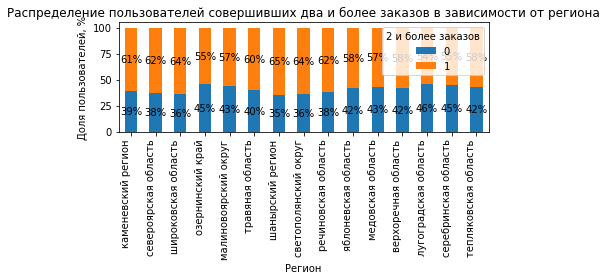

In [70]:
#Визуализируем распределение пользователей совершивших два и более заказов в зависимости от региона
plt_by_region_is_two_sorted = pivot_by_region_is_two_sorted.head(15)

plt.figure(figsize=(7, 4))
plt_by_region_is_two_sorted[[0, 1]].plot(kind='bar', stacked=True)

plt.title('Распределение пользователей совершивших два и более заказов в зависимости от региона')
plt.xlabel('Регион')
plt.ylabel('Доля пользователей, %')
plt.legend(['0', '1'], title='2 и более заказов')
plt.xticks(ha='right')

for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.0f%%', label_type='center', fontsize=10)

plt.tight_layout()
plt.show()

**Задача 4.1.2.** Промежуточный вывод

Средняя доля пользователей совершивших два и более заказов: 60.1%.
- `event_type_main`: Пользователи, совершившие первый заказ с desktop, возвращаются чаще среднего - 63%. Мобильные пользователи показывают результат как средний, и незначительно ниже результата desktop;
- `device_type_canonical`: возвращаемость 2+ раз в зависимости от типа мероприятия близка к средней возвращаемости 2+. Самый низкий показатель 54% у спортивных мероприятий, самые высокие - 62% и 63% у театра и выставок соответственно.
- `service_name` и `region_name`: возвращаемость 2+ у основных операторов в диапазоне 58-64%. Операторы с малой базой опять показывают больший разброс, что нормально т.к. по маленькой базе статистически могут быть ошибки. Зависимости между возвращаемостью 2+ и билетным оператором или регионом не выявлено. поэтому самыми крупными регионами по возвращаемости 2+ остаются просто самые большие регионы с точки срения количества кубленных билетов, а самыми крупными операторами по возвращаемости 2+ также просто операторы с максимальным колисечтвом пользовательского вовлечения.

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:  

- Гипотеза 1. Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- Гипотеза 2. В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

**Задача 4.1.3.** Промежуточный вывод

**Вывод по Гипотезе 1**

`Гипотеза не подтвердилась`
Пользователи, совершившие первый заказ на спортивные мероприятия, возвращаются реже (54.1%), чем пользователи, начавшие с концертов (60.8%). Фактически, спорт демонстрирует самую низкую возвращаемость среди всех типов мероприятий, а концерты показывают результат выше среднего.

**Вывод по Гипотезе 2**  
`Гипотеза не подтвердилась`
В наиболее активных регионах возвращаемость действительно выше среднего, но не всегда (озернинский край - 54.6%, малиновоярский округ - 54.4%). Т.о. нез зависимости между количеством заказов и повторной возвращаемостью пользователей.

### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.
Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета ( avg_revenue_rub ):
для пользователей, совершивших один заказ;
для вернувшихся пользователей, совершивших 2 и более заказа.

**Ответьте на вопросы:** 
В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
Есть ли различия между группами?

**Рекомендации:**
Используйте одинаковые интервалы ( bins ) и прозрачность ( alpha ), чтобы визуально сопоставить распределения.
Задайте параметру density значение True, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

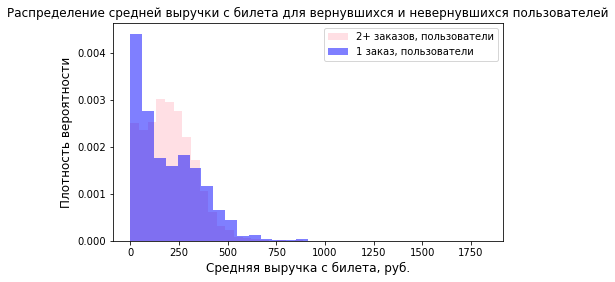

In [71]:
one_order_df = users_df[(users_df['is_two']==0)]['avg_ticket_revenue']
twomore_order_df = users_df[(users_df['is_two']==1)]['avg_ticket_revenue']

plt.figure(figsize=(7, 4))
plt.hist(x=twomore_order_df, label='2+ заказов, пользователи', alpha=0.5, bins=30, density=True, color='pink')
plt.hist(x=one_order_df, label='1 заказ, пользователи', alpha=0.5, bins=30, density=True, color='blue')

plt.title('Распределение средней выручки с билета для вернувшихся и невернувшихся пользователей', fontsize=12)
plt.xlabel('Средняя выручка с билета, руб.', fontsize=12)
plt.ylabel('Плотность вероятности', fontsize=12)
plt.legend()
plt.show()


In [72]:
one_order_df.describe()

count    8205.000000
mean      191.814164
std       158.797464
min         0.000000
25%        54.876667
50%       157.450000
75%       303.205000
max      1825.650000
Name: avg_ticket_revenue, dtype: float64

In [73]:
twomore_order_df.describe()

count    12334.000000
mean       200.421814
std        125.929878
min          0.000000
25%        103.509554
50%        190.792708
75%        280.044356
max       1332.778333
Name: avg_ticket_revenue, dtype: float64

**Задача 4.2.1.** Промежуточный вывод

- Пользователи с 1 заказом в среднем платили за билет  191 руб ( медиана 158 руб). Есть пользователи с очень дорогими билетами (до 1825 руб). Основной диапазон средней стоимости билета: от 54 руб до 303 руб (между 25 и 75 перцентилями). В этой группе большей перевес наблюдается в сторону более дешевых билетов, до 100 руб.
- Пользователи с 2+ заказами в среднем платили за билет чуть больше - 200 руб. Медиана также выше и близка к среднему (190 руб). Максимальная стоимость билета до 1332 руб, поэтому в частности медиана от среднего не так сильно отличается как в первой группе. Основной диапазон средней стоимости билета также уже чем в первой группе: от 103 руб до 280 руб (между 25 и 75 перцентилями).

ДА, различия между пользователями существуют:  
- Вернувшиеся пользователи покупают более дорогие билеты
- Вернувшиеся пользователи более стабильны в своих тратах — меньше разброс значений
- Дешевые билеты (<100 руб.) — среди покупающих очень дешевые билеты доля вернувшихся значительно ниже
- Очень дорогие билеты (>1000 руб.) чаще встречаются у невернувшихся — возможно, это "подарочные" покупки

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

**Ответьте на вопрос:** есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

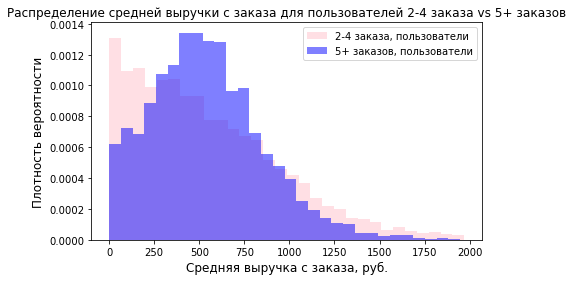

In [74]:
two_four_order_df = users_df[(users_df['orders_count']>=2)&(users_df['orders_count']<=4)]['avg_order_revenue']
fivemore_order_df = users_df[(users_df['orders_count']>=5)]['avg_order_revenue']
                                                       
plt.figure(figsize=(7, 4))
plt.hist(x=two_four_order_df, label='2-4 заказа, пользователи', alpha=0.5, bins=30, density=True, color='pink')
plt.hist(x=fivemore_order_df, label='5+ заказов, пользователи', alpha=0.5, bins=30, density=True, color='blue')

plt.title('Распределение средней выручки с заказа для пользователей 2-4 заказа vs 5+ заказов', fontsize=12)
plt.xlabel('Средняя выручка с заказа, руб.', fontsize=12)
plt.ylabel('Плотность вероятности', fontsize=12)
plt.legend()
plt.show()

In [75]:
two_four_order_df.describe()

count    7098.000000
mean      542.087024
std       401.045533
min         0.000000
25%       218.087500
50%       468.262500
75%       791.841250
max      1970.310000
Name: avg_order_revenue, dtype: float64

In [76]:
fivemore_order_df.describe()

count    5236.000000
mean      541.424737
std       310.402088
min         0.000000
25%       316.803696
50%       514.580750
75%       728.085250
max      1945.830000
Name: avg_order_revenue, dtype: float64

**Задача 4.2.2.** Промежуточный вывод

- Пользователи с 2-4 заказами в среднем платили за заказ 542 руб (медиана 468 руб). Максимальная стоимость заказа 1970. Основной диапазон: от 218 до 792 руб. (между 25 и 75 перцентилями). Широкий разброс значений (стандартное отклонение 401, выше чем в группе 5+), есть заметный "хвост" как в дешевую, так и в дорогую сторону
- Пользователи с 5+ заказами в среднем платили за заказ 541 руб (медиана 514 руб). Основной диапазон: от 317 до 728 руб. (между 25 и 75 перцентилями). Распределение более равномерное — пользователи более стабильны в своих тратах.

Различия межлу пользователями:
- Активные пользователи (5+ заказов) реже покупают в низком ценновом сегменте: 25 перцентиль 317 руб. против 218 руб. у группы 2-4 заказа
- Активные пользователи более однородны по своим тратам (стандартное отклонение 310 vs 401)
- Активные пользователи тратят на 46 руб. больше за медавнный заказ (515 руб. vs 468 руб.)
- Активные пользователи более стабильны в своих тратах - более симметричное распределение

Рекомендация:
- фокусироваться на переводе клиентов в Активную группу (5+ заказов) т.к. это более стабильная и кост эффективная группа.

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

Изучите распределение пользователей по среднему количеству билетов в заказе ( avg_tickets_count ) и опишите основные наблюдения.
Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:  
- от 1 до 2 билетов;
- от 2 до 3 билетов;
- от 3 до 5 билетов;
- от 5 и более билетов.  
Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.

**Ответьте на вопросы:**
- Как распределены пользователи по сегментам — равномерно или сконцентрировано?
- Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

In [77]:
bins = [1, 2, 3, 5, float('inf')]
labels = ['1-2 билета', '2-3 билета', '3-5 билетов', '>5 билетов']

users_df['tickets_category'] = pd.cut(users_df['avg_tickets_count'], bins=bins, labels=labels, right=True, include_lowest=True)
tickets_bin_df = users_df.groupby('tickets_category').agg(
    users_count=('is_two', 'count'),
    returned_users=('is_two', 'sum')
).reset_index()
tickets_bin_df['returned_share'] = (tickets_bin_df['returned_users'] / tickets_bin_df['users_count'] * 100).round(1)
tickets_bin_df

,tickets_category,users_count,returned_users,returned_share
0,1-2 билета,6140,2461.0,40.1
1,2-3 билета,9113,6600.0,72.4
2,3-5 билетов,5107,3217.0,63.0
3,>5 билетов,179,56.0,31.3


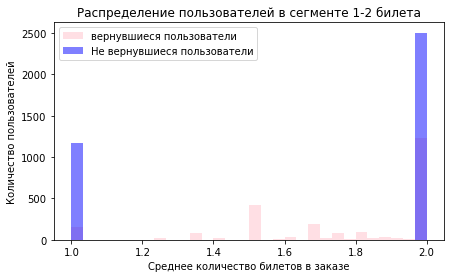

In [78]:
#Визуализируем рраспределение пользователей по среднему количеству билетов в заказе в сегменте от 1 до 2 билетов
one_two_single_df = users_df[(users_df['tickets_category']=='1-2 билета')&(users_df['orders_count']==1)]['avg_tickets_count']
one_two_rep_df = users_df[(users_df['tickets_category']=='1-2 билета')&(users_df['orders_count']>1)]['avg_tickets_count']

plt.figure(figsize=(7, 4))
plt.hist(x=one_two_rep_df, label='вернувшиеся пользователи', alpha=0.5, bins=30, color='pink')
plt.hist(x=one_two_single_df, label='Не вернувшиеся пользователи', alpha=0.5, bins=30, color='blue')

plt.title('Распределение пользователей в сегменте 1-2 билета')
plt.xlabel('Среднее количество билетов в заказе')
plt.ylabel('Количество пользователей')
plt.legend()
plt.show()

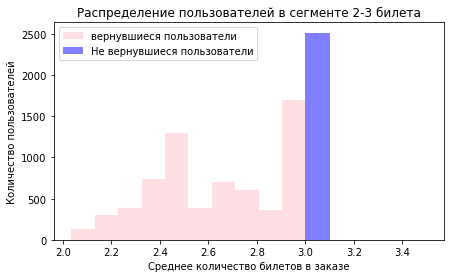

In [79]:
#Визуализируем рраспределение пользователей по среднему количеству билетов в заказе в сегменте от 2 до 3 билетов
two_three_single_df = users_df[(users_df['tickets_category']=='2-3 билета')&(users_df['orders_count']==1)]['avg_tickets_count']
two_three_rep_df = users_df[(users_df['tickets_category']=='2-3 билета')&(users_df['orders_count']>1)]['avg_tickets_count']

plt.figure(figsize=(7, 4))
plt.hist(x=two_three_rep_df, label='вернувшиеся пользователи', alpha=0.5, bins=10, color='pink')
plt.hist(x=two_three_single_df, label='Не вернувшиеся пользователи', alpha=0.5, bins=10, color='blue')

plt.title('Распределение пользователей в сегменте 2-3 билета')
plt.xlabel('Среднее количество билетов в заказе')
plt.ylabel('Количество пользователей')
plt.legend()
plt.show()

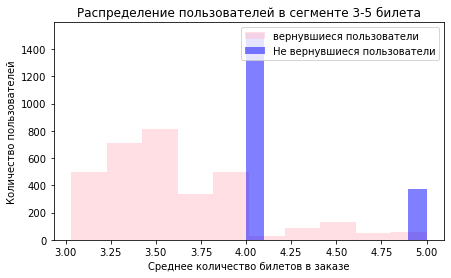

In [80]:
#Визуализируем рраспределение пользователей по среднему количеству билетов в заказе в сегменте от 3 до 5 билетов
three_five_single_df = users_df[(users_df['tickets_category']=='3-5 билетов')&(users_df['orders_count']==1)]['avg_tickets_count']
three_five_rep_df = users_df[(users_df['tickets_category']=='3-5 билетов')&(users_df['orders_count']>1)]['avg_tickets_count']

plt.figure(figsize=(7, 4))
plt.hist(x=three_five_rep_df, label='вернувшиеся пользователи', alpha=0.5, bins=10, color='pink')
plt.hist(x=three_five_single_df, label='Не вернувшиеся пользователи', alpha=0.5, bins=10, color='blue')

plt.title('Распределение пользователей в сегменте 3-5 билета')
plt.xlabel('Среднее количество билетов в заказе')
plt.ylabel('Количество пользователей')
plt.legend()
plt.show()

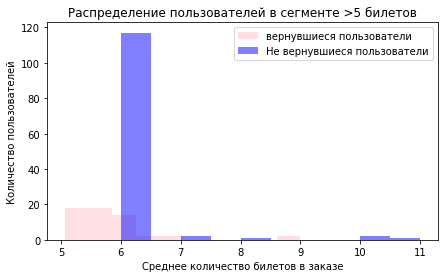

In [81]:
#Визуализируем рраспределение пользователей по среднему количеству билетов в заказе в сегменте от 3 до 5 билетов
fivemore_single_df = users_df[(users_df['tickets_category']=='>5 билетов')&(users_df['orders_count']==1)]['avg_tickets_count']
fivemoree_rep_df = users_df[(users_df['tickets_category']=='>5 билетов')&(users_df['orders_count']>1)]['avg_tickets_count']

plt.figure(figsize=(7, 4))
plt.hist(x=fivemoree_rep_df, label='вернувшиеся пользователи', alpha=0.5, bins=10, color='pink')
plt.hist(x=fivemore_single_df, label='Не вернувшиеся пользователи', alpha=0.5, bins=10, color='blue')

plt.title('Распределение пользователей в сегменте >5 билетов')
plt.xlabel('Среднее количество билетов в заказе')
plt.ylabel('Количество пользователей')
plt.legend()
plt.show()

**Задача 4.2.3.** Промежуточный вывод

Как распределены пользователи по сегментам — равномерно или сконцентрировано?
- Общее число пользователей в сегментах: ссновной объем пользователей находится в сегменте 2-3 билета (почти половина всех пользователей). Сегмент >5 билетов крайне малочисленен (всего 179 пользователей, около 1%). Сегменты 1-2 билета и 3-5 билетов имеют сопоставимые размеры (около 30% и 25% соответственно).
- Доля пользователей, совершивших повторные заказы: доля повторных покупок в сегментах 2-3 билета (72.4%) и 3-5 билета (63%) максимальная, в сегменте >5 билетов (31.3%) — самый низкий показатель, в сегменте 1-2 билета (40.1%) — также значительно ниже среднего.

Есть ли сегменты с аномально высокой или низкой долей повторных покупок?
- Аномально высокая доля повторных покупок в сегменте 2-3 билета (72.4%) — это максимальный показатель среди всех сегментов. В сегменте 2-3 билета распределение вернувшихся пользователей значительно преобладает над невернувшимися практически во всех подгруппах


### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:
день недели первой покупки;
время с момента первой покупки — лайфтайм;
средний интервал между покупками пользователей с повторными заказами.

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.  
По данным даты первого заказа выделите день недели.
Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

In [82]:
#Добавляем столбец с днем недели из столбца first_order
users_df['day'] = users_df['first_order'].dt.day_name()
users_df.head()

,user_id,first_order,last_order,orders_count,avg_order_revenue,avg_tickets_count,avg_days_since_prev,avg_ticket_revenue,order_ts,device_type_canonical,region_name,service_name,event_type_main,is_five,is_two,is_return,tickets_category,day
0,0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03,1,1521.940000,4.000000,NaN,380.485000,2024-08-20 16:08:03,mobile,каменевский регион,край билетов,театр,0,0,0,3-5 билетов,Tuesday
1,0005ca5e93f2cf4,2024-07-23 18:36:24,2024-10-06 13:56:02,2,774.010000,3.000000,75.0,229.683750,2024-07-23 18:36:24,mobile,каменевский регион,мой билет,выставки,0,1,1,2-3 билета,Tuesday
2,000898990054619,2024-07-13 19:40:48,2024-10-23 15:12:00,3,767.213333,2.666667,51.0,256.209444,2024-07-13 19:40:48,mobile,североярская область,лови билет!,другое,0,1,1,2-3 билета,Saturday
3,00096d1f542ab2b,2024-08-15 16:48:48,2024-08-15 16:48:48,1,917.830000,4.000000,NaN,229.457500,2024-08-15 16:48:48,desktop,каменевский регион,край билетов,театр,0,0,0,3-5 билетов,Thursday
4,000a55a418c128c,2024-09-29 19:39:12,2024-10-15 10:29:04,2,61.310000,1.500000,16.0,42.600000,2024-09-29 19:39:12,mobile,поленовский край,лучшие билеты,театр,0,1,1,1-2 билета,Sunday


In [83]:
users_df['day'].unique()

array(['Tuesday', 'Saturday', 'Thursday', 'Sunday', 'Monday', 'Wednesday',
       'Friday'], dtype=object)

In [84]:
#Делаем столбец day категориальным 
day_category = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
users_df['day'] = pd.Categorical(users_df['day'], categories = day_category, ordered = True)

by_day_df = users_df.groupby(['day', 'is_return'])['user_id'].count().reset_index()
by_day_df.head(14)

,day,is_return,user_id
0,Monday,0,1058
1,Monday,1,1729
2,Tuesday,0,1186
3,Tuesday,1,1802
4,Wednesday,0,1134
5,Wednesday,1,1795
6,Thursday,0,1240
7,Thursday,1,1757
8,Friday,0,1289
9,Friday,1,1840


<Figure size 648x288 with 0 Axes>

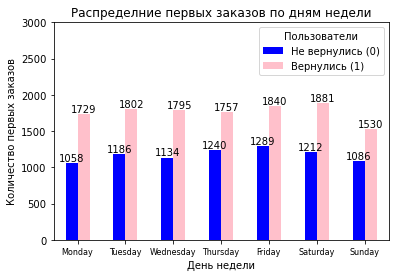

In [85]:
#Визуализируем 
plt.figure(figsize=(9, 4))
by_day_df.pivot(index='day', columns='is_return', values='user_id').plot(kind='bar', color=['blue', 'pink'])

plt.title('Распределние первых заказов по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество первых заказов')
plt.legend(['Не вернулись (0)', 'Вернулись (1)'], title='Пользователи')

for container in plt.gca().containers:
    plt.gca().bar_label(container, label_type='edge')
plt.xticks(rotation=0, ha='center', fontsize=8)
plt.ylim(0, 3000)

plt.show()


**Задача 4.3.1.** Промежуточный вывод

Влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

День недели первой покупки оказывает слабое влияние на вероятность возврата клиента. Разница между лучшим днем (понедельник, 62.0%) и худшим днем (воскресенье, 58.5%) составляет всего 3.5 процентных пункта.

- Начало недели (пн-ср) показывает чуть более высокий возврат (около 61-62%)
- Конец недели (чт-вс) показывает чуть более низкий возврат (около 58-59%)

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.  

Рассчитайте среднее время между заказами для двух групп пользователей:
- совершившие 2–4 заказа;  
- совершившие 5 и более заказов. 

Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

In [86]:
day_difference = users_df.groupby(['is_five']).agg({
    'user_id': 'count',
    'avg_days_since_prev': 'mean',
    'avg_order_revenue': ['mean', 'sum', 'min', 'max']})
day_difference.columns = ['total_users', 'avg_days', 'avg_revenue_mean', 'avg_revenue_sum', 'avg_revenue_min', 'avg_revenue_max']
day_difference['avg_revenue_mean'] = day_difference['avg_revenue_mean'].round(2)
day_difference['avg_revenue_sum'] = day_difference['avg_revenue_sum'].astype(int)
day_difference

,total_users,avg_days,avg_revenue_mean,avg_revenue_sum,avg_revenue_min,avg_revenue_max
is_five,,,,,,
0,15303,21.485137,526.14,8051537,0.0,1975.14
1,5236,11.136149,541.42,2834899,0.0,1945.83


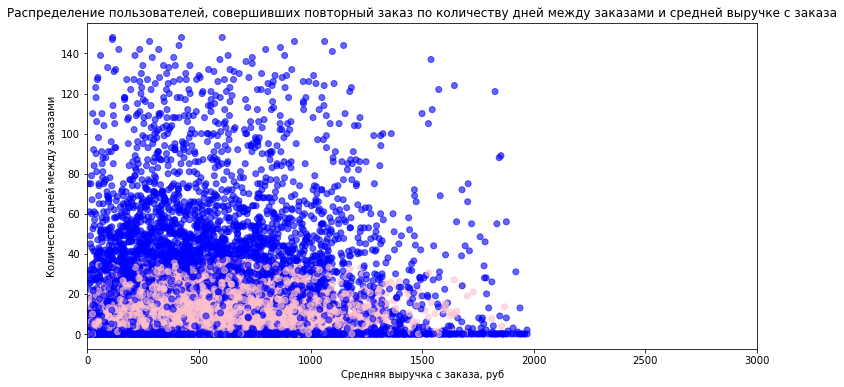

In [87]:
#Отсортируем только группу вернувщихся клиентов для визуализации
df_sorted = users_df[users_df['is_return']==1]

colors = {0: 'blue', 1: 'pink'}
plt.figure(figsize=(12, 6))
plt.scatter(x=df_sorted['avg_order_revenue'], 
           y=df_sorted['avg_days_since_prev'],
           c=df_sorted['is_five'].map(colors),
           alpha=0.6)

plt.title('Распределение пользователей, совершивших повторный заказ по количеству дней между заказами и средней выручке с заказа')
plt.xlabel('Средняя выручка с заказа, руб')
plt.ylabel('Количество дней между заказами')
plt.xlim((0, 3000))
plt.show()


**Задача 4.3.2.** Промежуточный вывод

- Клиенты с 5+ заказами возвращаются почти в 2 раза быстрее (11.1 дней  vs 21.5 дней) - поэтому да, можно сказать о присудствии  обратная корреляции: чем меньше интервал между заказами тем больше вероятность учеличения кратности заказов.
- Клиенты, возвращающиеся в течение 11 дней, с высокой вероятностью совершат 5+ покупок, а интервал более 21 дня характерен для менее лояльных клиентов (2-4 покупки)
- Клиенты с 5+ заказами в среднем имеют выше средний чек но не значительно (541.4 руб vs 526.1 руб). Также в группе 2-4 заказа присутствуют очень дорогие заказы? так же как и в группе 5+. Поэтому можно стелать вывод что лояльность определяется регулярностью, а не суммой покупок.

**Рекомендации для бизнеса:**
- Стремиться к интервалу менее 14 дней для формирования привычки покупок
- Внедрить программы лояльности с бонусами за покупки в течение 14 дней
- Создать систему напоминаний через 10-14 дней после покупки


### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. 
Для этого используйте универсальный коэффициент корреляции phi_k, который позволяет анализировать как числовые, так и категориальные признаки.

**Задача 4.4.1** Проведите корреляционный анализ:  
    
Рассчитайте коэффициент корреляции phi_k между признаками профиля пользователя и числом заказов ( total_orders ). При необходимости используйте параметр interval_cols для определения интервальных данных.
Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в total_orders. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю total_orders, а затем повторите корреляционный анализ. Выделите такие сегменты:
- 1 заказ;  
- от 2 до 4 заказов;  
- от 5 и выше.  

Визуализируйте результат корреляции с помощью тепловой карты.

**Ответьте на вопрос:** какие признаки наиболее связаны с количеством заказов?

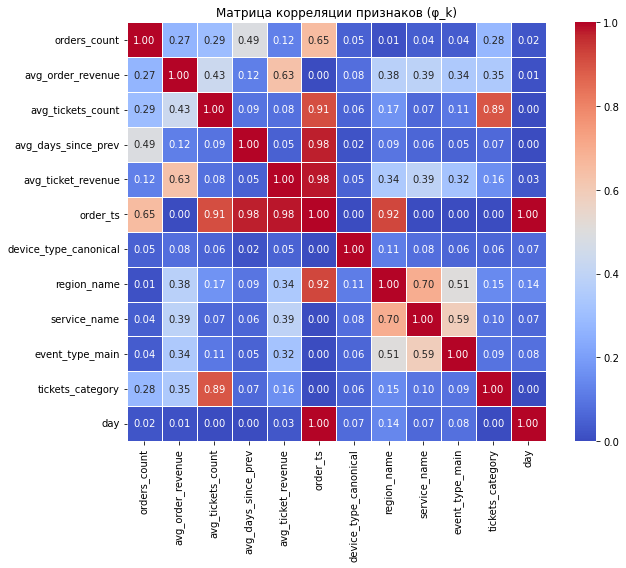

In [104]:
corr_df = users_df.drop(columns=['first_order', 'last_order', 'user_id', 'is_five', 'is_two', 'is_return'])

interval_cols = ['orders_count', 'avg_order_revenue', 'avg_tickets_count', 
                 'avg_days_since_prev', 'avg_ticket_revenue']
corr_matrix = corr_df.phik_matrix(interval_cols=interval_cols)


plt.figure(figsize=(10, 8))
sns.heatmap(data=corr_matrix, 
            annot=True,
            fmt='.2f',
            linewidths=0.5,
            cmap='coolwarm',
            square=True)

plt.title('Матрица корреляции признаков (φ_k)')
plt.tight_layout()
plt.show()

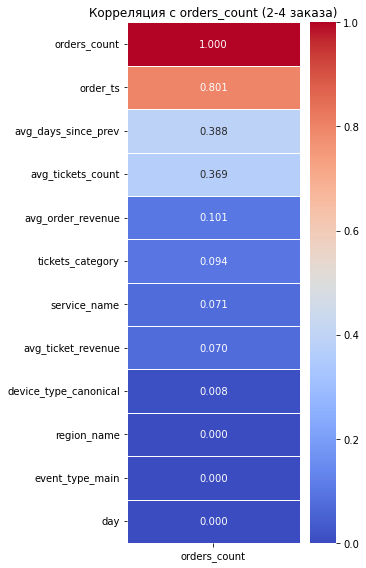

In [106]:
corr_df_two_four = corr_df[(corr_df['orders_count']>=2) & (corr_df['orders_count']<=4)]

corr_matrix_two_four = corr_df_two_four.phik_matrix(interval_cols=interval_cols)
corr_matrix_two_four_orders = corr_matrix_two_four[['orders_count']].sort_values('orders_count', ascending=False)
        
# Визуализация
plt.figure(figsize=(5, 8))
sns.heatmap(data=corr_matrix_two_four_orders, 
            annot=True, 
            fmt='.3f',
            linewidths=0.5,
            cmap='coolwarm')
plt.title('Корреляция с orders_count (2-4 заказа)')
plt.tight_layout()

plt.show()

**Задача 4.4.1.** Промежуточный вывод


### 5. Общие выводы и рекомендации

1. Информация о данных и их подготовке
В ходе проекта были проанализированы данные о покупках билетов на Яндекс Афише за период с июня по октябрь 2024 года. Исходный датасет содержал 290 611 записей о заказах.

- Приведение выручки к единой валюте (рубли) с использованием курса тенге
- Фильтрация выбросов по 99-му перцентилю в поле revenue_rub (удалено 1.1% записей)
- Приведение текстовых полей к нижнему регистру
- Построение профилей пользователей (21 838 уникальных пользователей)
- Фильтрация пользователей по 95-му перцентилю количества заказов и 99-му перцентилю средней выручки (итоговая выборка: 20 539 пользователей)

2. Основные статистические показатели
- Общее число пользователей: 20 539
- Средняя выручка с заказа: 530 руб.
- Доля пользователей с 2+ заказами: 60.1%
- Доля пользователей с 5+ заказами: 25.5%
- Общее число заказов: 83 699
- Среднее количество билетов в заказе: 3
- Средний интервал между заказами: 17 дней

При удалении всего 5.95% пользователей количество заказов сократилось на 70.9%, что подтверждает наличие небольшой группы очень активных пользователей, генерирующих основную массу заказов.

3. Ключевые результаты анализа
- Пользователи неравномерно распределены по сегментам, но доля вернувшихся относительно стабильна (60-63%) в крупных сегментах.
- Оптимальный сегмент для удержания клиентов — 2-3 билета в заказе (72.4% возврата).
- Влияние дня недели первой покупки и возвращаемостью клиентов есть, но незначительное (разрыв 3.6 п.п.)
- лояльность определяется регулярностью, а не суммой покупок.
- Корреляционный анализ. Наиболее связанные с количеством заказов признаки: среднее количество дней между заказами (умеренная корреляция); средняя выручка с заказа (слабая корреляция) и среднее количество билетов (слабая корреляция)

4. Рекомендации для бизнеса
- Высокий потенциал к возврату у пользователей начинающих с выставок и театра (62-63% возврата). Такие билеты важно иметь в арсенале
- Также высокий потенциал к возврату у пользователей покупающих 2-3 билета в заказе (72.4% возврата), поэтому важно стимулировать частоту покупок
- Целевой интервал между заказами: менее 14 дней. Мотивированик возврат: внедрить программу лояльности с бонусами за покупки в течение 14 дней, создать систему напоминаний через 10-14 дней после последней покупки. 
- Цена: мы видели что у пользователей с высокой частотой возврата не сильно пердставлены покупки в низком ценовом сегменте, поэтому надо стимулировать переход из низкого ценового сегмента (<100 руб. за билет) в средний.
- Сегментирование коммуникации: покупуки с чт по вт дают чуть больший процент вернувшихся, поэтому усилить коммуникацию с чт по вс
- ГЕО: Сфокусироваться на топ-регионах (каменевский регион, североярская область) — там основная масса пользователей
- Операторы - Укрепить сотрудничество с ТОП операторами

5. Ключевые метрики для мониторинга
- Доля пользователей с 2+ заказами (целевой уровень: >60%)
- Средний интервал между заказами (целевой уровень: <14 дней)
- Доля пользователей в сегменте 2-3 билета (целевой уровень: >44%)
- Средняя выручка с заказа в группе 5+ заказов (целевой уровень: >540 руб.)

**Заключение**
Наиболее перспективная стратегия удержания клиентов — фокус на частоте покупок и сегменте 2-3 билета. Пользователи, возвращающиеся в течение двух недель и покупающие 2-3 билета, с вероятностью более 70% становятся постоянными клиентами и переходят в группу с 5+ заказами. При этом размер среднего чека играет второстепенную роль по сравнению с регулярностью покупок.